<h1 align="center"><b>Homework Assignment 4 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 9</b></h3>
<h3 align="center"><b>Due at the end of Module 11</b></h3><br>

### Author: Robert Feconda
- Email: rfecond1@jh.edu

# Q1 — Designing and Solving Your Own Reinforcement Learning Environment

## 30 points total

### [15 points] Part A – Design and Implement a Custom RL Environment

__Goal:__ Define and implement a small custom environment that can be solved using **Q-Learning** 

1. Use the [Gymnasium API structure](https://gymnasium.farama.org/introduction/create_custom_env/): 

```python
# starter code if you need it. Use documentation. Focus on design rather than syntax. 
import gymnasium as gym
from gymnasium import spaces

class CustomEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Discrete(...)
        self.action_space = spaces.Discrete(...)
        # define internal dynamics

    def reset(self, seed=None, options=None):
        # return initial state, info
        return state, {}

    def step(self, action):
        # define transitions, rewards, terminal condition
        return next_state, reward, terminated, truncated, {}
```
2. Choose one of these types of problems:

   - Grid-based navigation (agent finds goal, avoids obstacles)
   - Resource management (agent balances energy/reward trade-offs)
   - Sequential decision process (agent makes timed choices with delayed reward)

3. Your environment must have:

   - At least 8–12 discrete states
   - At least 2–4 actions
   - Clearly defined stochastic or deterministic transitions
   - A nontrivial reward structure (some decisions should require exploration)

4. Include a diagram of your environment (state transitions, rewards, or layout).
---

### [15 points] Part B – Apply Q-Learning and Analyze Results

- Implement Q-Learning
- Train for 1000+ episodes
- Plot:
  - Moving average of total episode reward
  - Final Q-table
  - Learning policy visualization

Analysis:
1. What did the agent learn?
   - Describe the final policy and what behaviors emerged
2. How does your reward design affect convergence?
   - Did the agent learn what you expected?
3. If you adjusted $\gamma$ or $\epsilon$, how did learning change?
4. What are the failure modes?
   - What would make your environment "harder" or "easier"?



## Q1 Response

### Design using Gymnasium Documentation outline
- What skill should the agent learn?
  - A drone will learn to navigate through a city landscape and avoid buildings to find a target location to deliver a package.
  - The world is a 3-dimensional box world
- What information does the agent need?
  - Position and velocity is required
  - Full obervability is required. Partial observability would require state estimation and a richer model and extensive memory. Not in scope for this environment. 
- What actions can the agent take?
  - Discrete choices: up, down, left, right, forward, backward, 25% power, 50% power, 75% power, 100% power.
  - The discrete movement choices are defined as initial starting point + movement:
    - move + x
    - move - x
    - move + y
    - move - y
    - move + z
    - move - z
  - To keep it simple, each position in the grid world is unitized and discrete.
  - Each heading change costs a small negative reward. 
  - The state is position and remaining battery
  - The actions are direction + power level
- How do we measure success?
  - The agent must reach its delivery location. It could be anywhere in the 3 dimensional box world.
  - The agent will receive a higher final score for minimizing time to delivery location
  - Avoid building collissions. A single collission is immediate failure.
  - Minimize the amount of actions required as each change in velocity and heading requires energy from battery
  - Reward function: penalize time and energy use, heavily reward reaching goal, heavy penalize battery depletion or crashing
- When should episodes end?
  - Destination reached
  - Battery depleted
  - If a collission occurs

<!-- codex-q1-part-a-start -->
### Part A - Custom Gymnasium Environment Implementation

I took some liberties with the original design so I could keep the implementation in simple tabular Q-learning instead of building a full drone physics simulator. If I used actual continuous velocity, continuous acceleration, or exact battery voltage, then the state space would no longer fit cleanly into a basic Q-table. I reduced those parts into discrete values. For example, I reduced battery from a continuous percentage or voltage reading into integer battery states from `0` to `20`. I also reduced velocity into a current heading, because the important learning tradeoff in this environment is whether changing direction costs extra energy/time.

The same idea applies to power. I kept the four power levels from my design, but I made each one a fixed grid movement and battery cost. This gives the agent a meaningful energy tradeoff without hiding the problem behind complicated physics.

**Environment design**

- **World:** a deterministic `6 x 6 x 3` city grid. The drone starts at `(0, 0, 0)` and must deliver to `(5, 5, 2)`.
- **Hazards:** buildings occupy blocked grid cells and always start at the ground layer. A building column may rise to `z=0`, `z=1`, or `z=2`, but it cannot float above open air. Entering a building or leaving the city box ends the episode as a crash.
- **Observation:** one integer from `spaces.Discrete(...)`. The integer decodes to `(x, y, z, battery, heading)`, which keeps the environment fully observable and Markov for tabular Q-Learning.
- **Actions:** one integer from `spaces.Discrete(24)`. Each action is a direction and power pair: 6 directions times 4 power levels.
- **Transitions:** deterministic. The selected direction and power determine the intended path through the grid.
- **Rewards:** small penalties for time, energy, and heading changes; a large penalty for crashing or exhausting the battery; a large delivery bonus with a remaining-battery bonus.
- **Episode end:** delivery succeeds, crash occurs, battery reaches zero, or the max step count truncates the episode.

This larger grid gives the Q-learning agent a more substantial search problem than the smallest assignment minimum. The encoded state space is still manageable for a Q-table: `108` possible positions, `21` non-continuous integer battery states, and `7` heading states, for `15,876` possible encoded states before considering actions. With `24` actions, the Q-table has `381,024` values, which is large enough to be meaningful but still easy for my computer to train.

**Gymnasium documentation used**

- `gymnasium.Env` defines the environment API, including `action_space`, `observation_space`, `reset`, `step`, `render`, and `close`: https://gymnasium.farama.org/api/env/
- The custom-environment tutorial shows the same pattern used here: subclass `gymnasium.Env`, define spaces in `__init__`, implement helper methods for observations/info, call `super().reset(seed=seed)`, and return `(observation, info)` from `reset`: https://gymnasium.farama.org/introduction/create_custom_env/
- `Env.step()` returns `(observation, reward, terminated, truncated, info)`, using separate `terminated` and `truncated` flags: https://gymnasium.farama.org/api/env/
- `spaces.Discrete` represents a finite integer set, which fits both the encoded tabular state and action index used for Q-Learning: https://gymnasium.farama.org/main/api/spaces/fundamental/#gymnasium.spaces.Discrete
- `check_env` is recommended in the Gymnasium custom-environment guide as a way to catch common environment API mistakes: https://gymnasium.farama.org/introduction/create_custom_env/#debugging-your-environment


### Environment Layout Diagram

Coordinates are `(x, y, z)`. `S` is the start, `G` is the delivery target, `B` is a building, and `.` is open air. The three layers show the same city footprint at three altitude levels.

| `z = 2` upper layer | `z = 1` middle layer | `z = 0` lower layer |
|---|---|---|
| `.  .  .  .  .  G` | `.  .  B  .  .  .` | `.  .  B  .  .  .` |
| `B  .  .  B  .  .` | `B  .  .  B  .  .` | `B  .  .  B  .  .` |
| `.  .  .  B  .  .` | `.  .  .  B  .  B` | `.  .  .  B  .  B` |
| `.  B  .  .  .  .` | `.  B  B  .  .  .` | `.  B  B  .  B  .` |
| `.  .  .  .  .  .` | `.  .  .  B  .  .` | `.  .  .  B  .  .` |
| `.  .  .  .  .  .` | `.  .  .  .  .  .` | `S  .  .  .  .  .` |

Each building has a ground footprint at `z=0`. Some columns are one layer tall, while others extend upward to `z=1` or `z=2`. This keeps the city layout physically consistent while still giving the drone useful altitude choices.


In [ ]:
import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env
import numpy as np


class DroneDeliveryEnv(gym.Env):
    """A deterministic 3D drone delivery environment using the Gymnasium API.
    Gymnasium calls reset() at the start of an episode and step(action) at each
    agent decision. The public observation is one integer so we can store
    Q-values in a simple table: Q[state, action].
    """

    metadata = {"render_modes": ["ansi"], "render_fps": 4}

    def __init__(self, render_mode=None):
        """Create the city layout, action space, observation space, and state variables.
        This function is called once when the environment object is created, for
        example with env = DroneDeliveryEnv(). Gymnasium expects action_space and observation_space to be defined here.
        """
        super().__init__()

        # City geometry: x in [0, 5], y in [0, 5], z in [0, 2].
        self.width = 6
        self.depth = 6
        self.height = 3
        self.start = np.array([0, 0, 0], dtype=np.int64)
        self.goal = np.array([5, 5, 2], dtype=np.int64)
        # Buildings are defined as grounded columns: (x, y) -> highest z layer.
        # This avoids unrealistic floating buildings in upper altitude layers.
        building_columns = {
            (3, 1): 1,
            (1, 2): 2,
            (2, 2): 1,
            (4, 2): 0,
            (3, 3): 2,
            (5, 3): 1,
            (0, 4): 2,
            (3, 4): 2,
            (2, 5): 1,
        }
        self.buildings = {
            (x, y, z)
            for (x, y), highest_z in building_columns.items()
            for z in range(highest_z + 1)
        }

        # Battery and time limits keep episodes finite.
        self.max_battery = 20
        self.max_steps = 60
        self.render_mode = render_mode

        # Heading is included in the state because heading changes affect reward.
        self.heading_names = ["none", "+x", "-x", "+y", "-y", "+z", "-z"]
        self.directions = [
            ("+x", np.array([1, 0, 0], dtype=np.int64)),
            ("-x", np.array([-1, 0, 0], dtype=np.int64)),
            ("+y", np.array([0, 1, 0], dtype=np.int64)),
            ("-y", np.array([0, -1, 0], dtype=np.int64)),
            ("+z", np.array([0, 0, 1], dtype=np.int64)),
            ("-z", np.array([0, 0, -1], dtype=np.int64)),
        ]

        # Power level controls both travel distance and battery cost.
        self.power_levels = [
            ("25%", 1, 1),
            ("50%", 1, 2),
            ("75%", 2, 3),
            ("100%", 2, 4),
        ]

        # Each action index maps to a readable direction and power combination.
        self.action_table = []
        for direction_index, (direction_name, vector) in enumerate(self.directions):
            for power_name, distance, battery_cost in self.power_levels:
                self.action_table.append(
                    {
                        "direction_index": direction_index,
                        "direction": direction_name,
                        "vector": vector,
                        "power": power_name,
                        "distance": distance,
                        "battery_cost": battery_cost,
                        "name": f"move {direction_name} at {power_name}",
                    }
                )

        # Gymnasium spaces define what the agent is allowed to observe and do.
        self.action_space = spaces.Discrete(len(self.action_table))

        self.position_count = self.width * self.depth * self.height
        self.battery_count = self.max_battery + 1
        self.heading_count = len(self.heading_names)
        self.observation_space = spaces.Discrete(
            self.position_count * self.battery_count * self.heading_count
        )

        # Internal state variables are reset at the beginning of each episode.
        self._position = self.start.copy()
        self._battery = self.max_battery
        self._heading = 0
        self._steps = 0

    def _position_to_index(self, position):
        """Convert an (x, y, z) grid coordinate into one position index.
        This helper is called by _encode_state(). It lets the full 3D position
        become part of one integer observation for tabular Q-learning.
        """
        x, y, z = [int(value) for value in position]
        return x + self.width * (y + self.depth * z)

    def _index_to_position(self, position_index):
        """Convert one position index back into an (x, y, z) coordinate.
        This helper is called by decode_state() so printed states are readable.
        """
        z, remainder = divmod(int(position_index), self.width * self.depth)
        y, x = divmod(remainder, self.width)
        return np.array([x, y, z], dtype=np.int64)

    def _encode_state(self, position, battery, heading):
        """Pack position, battery, and heading into one integer observation.
        reset() and step() call this through _get_obs(). The Q-learning algorithm can then use the returned integer directly as the row index in the Q-table.
        """
        position_index = self._position_to_index(position)
        return int(
            (position_index * self.battery_count + int(battery)) * self.heading_count
            + int(heading)
        )

    def decode_state(self, state):
        """Convert an integer observation into readable state components.
        This is not required by Gymnasium, but it is useful for debugging and for explaining learned policies.
        """
        state = int(state)
        position_battery, heading = divmod(state, self.heading_count)
        position_index, battery = divmod(position_battery, self.battery_count)
        return {
            "position": self._index_to_position(position_index),
            "battery": int(battery),
            "heading": self.heading_names[int(heading)],
        }

    def _get_obs(self):
        """Return the current observation in Gymnasium's expected format.
        reset() and step() call this before returning to the agent.
        """
        return self._encode_state(self._position, self._battery, self._heading)

    def _manhattan_to_goal(self, position=None):
        """Measure grid distance from a position to the delivery goal.
        step() calls this before and after movement to give a small reward when
        the drone moves closer to the target.
        """
        if position is None:
            position = self._position
        return int(np.abs(position - self.goal).sum())

    def _get_info(self):
        """Return extra diagnostic information for analysis.
        Gymnasium returns info from reset() and step(). The learning algorithm does not need it, but it helps explain what happened after each action.
        """
        return {
            "position": self._position.copy(),
            "battery": int(self._battery),
            "heading": self.heading_names[int(self._heading)],
            "distance_to_goal": self._manhattan_to_goal(),
            "steps": int(self._steps),
        }

    def _in_bounds(self, position):
        """Check whether a coordinate is still inside the city airspace.
        step() calls this for every cell crossed by the chosen action. Leaving
        bounds ends the episode as a crash.
        """
        x, y, z = [int(value) for value in position]
        return 0 <= x < self.width and 0 <= y < self.depth and 0 <= z < self.height

    def _is_building(self, position):
        """Check whether a coordinate is occupied by a building.
        step() calls this for every cell crossed by the chosen action. Entering a building ends the episode as a crash.
        """
        return tuple(int(value) for value in position) in self.buildings

    def reset(self, seed=None, options=None):
        """Start a new episode and return (initial_observation, info).
        Gymnasium calls this before training/evaluation episodes. It places the
        drone back at the start, restores the battery, clears the heading, and
        returns the encoded initial state.
        """
        # Gymnasium recommends this call so Env handles seeding consistently.
        super().reset(seed=seed)

        self._position = self.start.copy()
        self._battery = self.max_battery
        self._heading = 0
        self._steps = 0

        observation = self._get_obs()
        info = self._get_info()
        if self.render_mode == "ansi":
            info["render"] = self.render()
        return observation, info

    def step(self, action):
        """Apply one action and return Gymnasium's five step values.
        The Q-learning loop calls this repeatedly. The return order is
        (observation, reward, terminated, truncated, info), matching the current
        Gymnasium API.
        """
        if not self.action_space.contains(action):
            raise ValueError(f"Action {action!r} is outside {self.action_space}.")

        action = int(action)
        action_spec = self.action_table[action]
        self._steps += 1

        previous_distance = self._manhattan_to_goal()
        previous_heading = self._heading
        new_heading = action_spec["direction_index"] + 1

        # Reward components are kept separate so the notebook can show why a
        # transition received its final reward.
        reward_components = {
            "time": -1.0,
            "energy": -0.25 * action_spec["battery_cost"],
            "heading_change": 0.0,
            "distance_shaping": 0.0,
            "goal": 0.0,
            "battery_empty": 0.0,
            "crash": 0.0,
        }
        if previous_heading != 0 and previous_heading != new_heading:
            reward_components["heading_change"] = -0.5

        terminated = False
        truncated = False
        crash_reason = None

        # High-power moves can cross more than one grid cell, so every crossed
        # cell must be checked for buildings and boundary violations.
        path_cells = [
            self._position + action_spec["vector"] * step
            for step in range(1, action_spec["distance"] + 1)
        ]

        for cell in path_cells:
            if not self._in_bounds(cell):
                crash_reason = "left city airspace"
                break
            if self._is_building(cell):
                crash_reason = "hit building"
                break

        if crash_reason is not None:
            reward_components["crash"] = -50.0
            terminated = True
        else:
            self._position = path_cells[-1]
            self._battery = max(0, self._battery - action_spec["battery_cost"])
            self._heading = new_heading

            new_distance = self._manhattan_to_goal()
            if new_distance < previous_distance:
                reward_components["distance_shaping"] = 1.0
            elif new_distance > previous_distance:
                reward_components["distance_shaping"] = -0.5

            if np.array_equal(self._position, self.goal):
                reward_components["goal"] = 60.0 + 2.0 * self._battery
                terminated = True
            elif self._battery == 0:
                reward_components["battery_empty"] = -25.0
                terminated = True

        if self._steps >= self.max_steps and not terminated:
            truncated = True

        reward = float(sum(reward_components.values()))
        observation = self._get_obs()
        info = self._get_info()
        info.update(
            {
                "action_name": action_spec["name"],
                "reward_components": reward_components,
                "crash_reason": crash_reason,
            }
        )
        if self.render_mode == "ansi":
            info["render"] = self.render()
        return observation, reward, bool(terminated), bool(truncated), info

    def render(self):
        """Return an ASCII drawing of the current city state.
        """
        layers = []
        drone_position = tuple(int(value) for value in self._position)
        start_position = tuple(int(value) for value in self.start)
        goal_position = tuple(int(value) for value in self.goal)

        for z in reversed(range(self.height)):
            lines = [f"z={z}"]
            for y in reversed(range(self.depth)):
                row = []
                for x in range(self.width):
                    cell = (x, y, z)
                    if cell == drone_position:
                        row.append("D")
                    elif cell == goal_position:
                        row.append("G")
                    elif cell in self.buildings:
                        row.append("B")
                    elif cell == start_position:
                        row.append("S")
                    else:
                        row.append(".")
                lines.append(" ".join(row))
            layers.append("\n".join(lines))
        return "\n\n".join(layers)

    def close(self):
        """Release environment resources.
        This environment does not open files or windows, so there is nothing to
        release. The method is included because Gymnasium environments commonly
        expose close().
        """
        pass


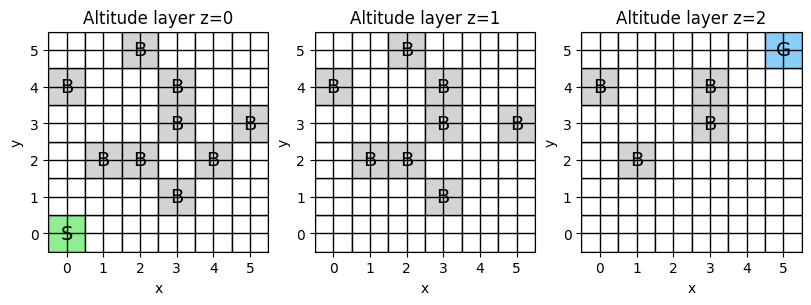

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def draw_drone_city_diagram(env):
    """Draw one 2D grid per altitude layer.
    """
    fig, axes = plt.subplots(1, env.height, figsize=(8, 4), constrained_layout=True)
    if env.height == 1:
        axes = [axes]

    for z, ax in enumerate(axes):
        ax.set_title(f"Altitude layer z={z}")
        ax.set_xlim(0, env.width)
        ax.set_ylim(0, env.depth)
        ax.set_aspect("equal")
        ax.set_xticks(np.arange(env.width) + 0.5, labels=range(env.width))
        ax.set_yticks(np.arange(env.depth) + 0.5, labels=range(env.depth))
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(color="black", linewidth=1)

        # Label each grid cell as start, goal, building, or open air.
        for x in range(env.width):
            for y in range(env.depth):
                cell = (x, y, z)
                facecolor = "white"
                label = ""
                if cell in env.buildings:
                    facecolor = "lightgray"
                    label = "B"
                if cell == tuple(env.start):
                    facecolor = "lightgreen"
                    label = "S"
                if cell == tuple(env.goal):
                    facecolor = "lightskyblue"
                    label = "G"

                ax.add_patch(Rectangle((x, y), 1, 1, facecolor=facecolor, edgecolor="black"))
                if label:
                    ax.text(x + 0.5, y + 0.5, label, ha="center", va="center", fontsize=14)

    return fig

diagram_env = DroneDeliveryEnv()
draw_drone_city_diagram(diagram_env)
plt.show()


In [13]:
env = DroneDeliveryEnv(render_mode="ansi")
check_env(DroneDeliveryEnv(), skip_render_check=True)

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Encoded states: {env.observation_space.n}")
print(f"Actions: {env.action_space.n}")

print("\nAction table:")
for action_index, action_spec in enumerate(env.action_table):
    print(f"{action_index:2d}: {action_spec['name']}")

obs, info = env.reset(seed=42)
print("\nInitial encoded observation:", obs)
print("Initial decoded observation:", env.decode_state(obs))
print("\nInitial layout:")
print(info["render"])


Observation space: Discrete(15876)
Action space: Discrete(24)
Encoded states: 15876
Actions: 24

Action table:
 0: move +x at 25%
 1: move +x at 50%
 2: move +x at 75%
 3: move +x at 100%
 4: move -x at 25%
 5: move -x at 50%
 6: move -x at 75%
 7: move -x at 100%
 8: move +y at 25%
 9: move +y at 50%
10: move +y at 75%
11: move +y at 100%
12: move -y at 25%
13: move -y at 50%
14: move -y at 75%
15: move -y at 100%
16: move +z at 25%
17: move +z at 50%
18: move +z at 75%
19: move +z at 100%
20: move -z at 25%
21: move -z at 50%
22: move -z at 75%
23: move -z at 100%

Initial encoded observation: 140
Initial decoded observation: {'position': array([0, 0, 0]), 'battery': 20, 'heading': 'none'}

Initial layout:
z=2
. . . . . G
B . . B . .
. . . B . .
. B . . . .
. . . . . .
. . . . . .

z=1
. . B . . .
B . . B . .
. . . B . B
. B B . . .
. . . B . .
. . . . . .

z=0
. . B . . .
B . . B . .
. . . B . B
. B B . B .
. . . B . .
D . . . . .


In [14]:
# A hand-coded safe route for API testing only.
# Part B will replace this with learned Q-values.
safe_route = [2, 2, 0, 10, 18, 10, 8]  # +x, +x, +x, +y, +z, +y, +y

obs, info = env.reset(seed=42)
total_reward = 0.0

for step_number, action in enumerate(safe_route, start=1):
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    print(
        f"step={step_number}, action={action:2d} ({info['action_name']}), "
        f"reward={reward:6.2f}, total={total_reward:6.2f}, "
        f"terminated={terminated}, truncated={truncated}"
    )
    print("decoded state:", env.decode_state(obs))
    print("reward components:", info["reward_components"])
    print()
    if terminated or truncated:
        break

print("Final layout:")
print(env.render())


step=1, action= 2 (move +x at 75%), reward= -0.75, total= -0.75, terminated=False, truncated=False
decoded state: {'position': array([2, 0, 0]), 'battery': 17, 'heading': '+x'}
reward components: {'time': -1.0, 'energy': -0.75, 'heading_change': 0.0, 'distance_shaping': 1.0, 'goal': 0.0, 'battery_empty': 0.0, 'crash': 0.0}

step=2, action= 2 (move +x at 75%), reward= -0.75, total= -1.50, terminated=False, truncated=False
decoded state: {'position': array([4, 0, 0]), 'battery': 14, 'heading': '+x'}
reward components: {'time': -1.0, 'energy': -0.75, 'heading_change': 0.0, 'distance_shaping': 1.0, 'goal': 0.0, 'battery_empty': 0.0, 'crash': 0.0}

step=3, action= 0 (move +x at 25%), reward= -0.25, total= -1.75, terminated=False, truncated=False
decoded state: {'position': array([5, 0, 0]), 'battery': 13, 'heading': '+x'}
reward components: {'time': -1.0, 'energy': -0.25, 'heading_change': 0.0, 'distance_shaping': 1.0, 'goal': 0.0, 'battery_empty': 0.0, 'crash': 0.0}

step=4, action=10 (mov

<!-- codex-q1-part-b-start -->
### Part B - Apply Q-Learning and Analyze Results

The Q-table has one row per encoded state and one column per action:

```text
Q[state, action] = expected discounted return
```

I use more than 1000 episodes because the larger `6 x 6 x 3` world has many crash states and the agent needs enough exploration to discover a safe delivery path. The training loop is still standard Q-learning: choose an action with epsilon-greedy exploration, step the environment, update one Q-value, and repeat until the episode ends.


In [ ]:
import pandas as pd


def moving_average(values, window_size):
    """Compute a simple moving average for smoother training plots."""
    values = np.asarray(values, dtype=float)
    if len(values) < window_size:
        return values
    weights = np.ones(window_size) / window_size
    # Using convolve to get the sliding average, weights are the kernel
    return np.convolve(values, weights, mode="valid")


def train_q_learning(
    env,
    episodes=12_000,
    alpha=0.15,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.9993,
    seed=42,
):
    """Training on the environment.

    The update rule is:
    Q(s, a) <- Q(s, a) + alpha * [r + gamma * max_a Q(s', a) - Q(s, a)]

    - Q(s, a): current estimate for taking action a in state s.
    - r: reward received immediately after taking the action.
    - max_a Q(s', a): best estimated future value from the next state s', 
    since we are fully observable this is known.
    - gamma: discount factor; how much I care about future reward.
    - r + gamma * max_a Q(s', a): better target estimate after seeing the result.
    - target - Q(s, a): prediction error, or how wrong the old estimate was.
    - alpha: learning rate; how strongly I move the old estimate toward the target.
    """
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.observation_space.n, env.action_space.n), dtype=np.float64)

    episode_rewards = []
    episode_lengths = []
    episode_successes = []
    epsilon_history = []

    epsilon = epsilon_start

    for episode in range(episodes):
        # s: current state. reset() gives the starting state for this episode.
        state, info = env.reset(seed=seed + episode)
        terminated = False
        truncated = False
        total_reward = 0.0
        steps = 0
        success = False

        while not (terminated or truncated):
            # a: action chosen from the current state s.
            # With probability epsilon I explore. Otherwise I choose the action
            # with the highest current Q(s, a) estimate.
            if rng.random() < epsilon:
                action = int(rng.integers(env.action_space.n))
            else:
                action = int(np.argmax(q_table[state]))

            # env.step(action) applies a and returns:
            # s' = next_state, r = reward, plus episode-ending flags.
            next_state, reward, terminated, truncated, info = env.step(action)

            # max_a Q(s', a): best future value from the next state.
            # If the episode ended, there is no future value left to add.
            if terminated or truncated:
                best_next_value = 0.0
            else:
                best_next_value = np.max(q_table[next_state])

            # r + gamma * max_a Q(s', a): new target estimate after seeing outcome.
            td_target = reward + gamma * best_next_value

            # [target - Q(s, a)]: how wrong the old estimate was.
            td_error = td_target - q_table[state, action]

            # Q(s, a) <- Q(s, a) + alpha * error:
            # update only the table entry for the state/action just experienced.
            q_table[state, action] += alpha * td_error

            # Move forward so the next loop iteration starts from s'.
            state = next_state
            total_reward += reward
            steps += 1
            success = terminated and np.array_equal(info["position"], env.goal)

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
        episode_successes.append(success)
        epsilon_history.append(epsilon)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

    history = {
        "episode_rewards": np.array(episode_rewards),
        "episode_lengths": np.array(episode_lengths),
        "episode_successes": np.array(episode_successes, dtype=float),
        "epsilon_history": np.array(epsilon_history),
    }
    return q_table, history


training_env = DroneDeliveryEnv()
q_table, history = train_q_learning(training_env)

recent_window = 500
print(f"Q-table shape: {q_table.shape}")
print(f"Mean reward over last {recent_window} episodes: {history['episode_rewards'][-recent_window:].mean():.2f}")
print(f"Success rate over last {recent_window} episodes: {history['episode_successes'][-recent_window:].mean():.2%}")
print(f"Mean episode length over last {recent_window} episodes: {history['episode_lengths'][-recent_window:].mean():.2f} steps")
print(f"Final epsilon: {history['epsilon_history'][-1]:.3f}")


Q-table shape: (15876, 24)
Mean reward over last 500 episodes: 22.14
Success rate over last 500 episodes: 66.80%
Mean episode length over last 500 episodes: 7.99 steps
Final epsilon: 0.050


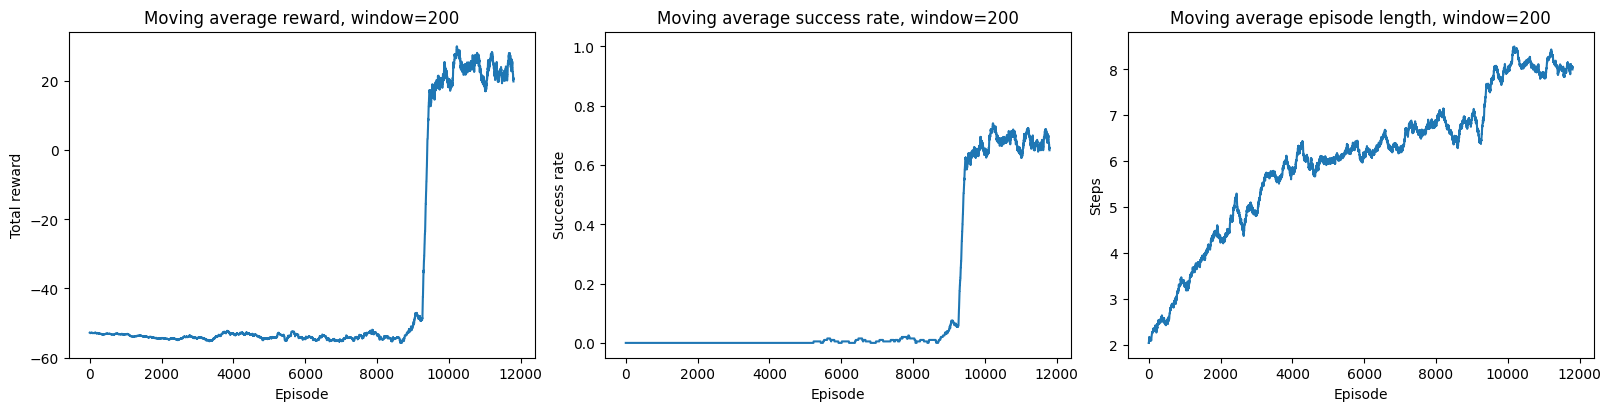

In [16]:
window_size = 200
reward_ma = moving_average(history["episode_rewards"], window_size)
success_ma = moving_average(history["episode_successes"], window_size)
length_ma = moving_average(history["episode_lengths"], window_size)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

axes[0].plot(reward_ma)
axes[0].set_title(f"Moving average reward, window={window_size}")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")

axes[1].plot(success_ma)
axes[1].set_title(f"Moving average success rate, window={window_size}")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Success rate")
axes[1].set_ylim(-0.05, 1.05)

axes[2].plot(length_ma)
axes[2].set_title(f"Moving average episode length, window={window_size}")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Steps")

plt.show()


In [17]:
def run_greedy_policy(env, q_table, max_steps=100, seed=123):
    """Run the learned greedy policy once from the start state.

    This function is separate from training so I can inspect what the final Q-table actually tells the drone to do.
    """
    state, info = env.reset(seed=seed)
    route = []
    total_reward = 0.0

    for step_number in range(1, max_steps + 1):
        action = int(np.argmax(q_table[state]))
        next_state, reward, terminated, truncated, info = env.step(action)
        route.append(
            {
                "step": step_number,
                "state": state,
                "action": action,
                "action_name": info["action_name"],
                "reward": reward,
                "position": tuple(int(value) for value in info["position"]),
                "battery": info["battery"],
                "heading": info["heading"],
                "terminated": terminated,
                "truncated": truncated,
                "crash_reason": info["crash_reason"],
            }
        )
        total_reward += reward
        state = next_state
        if terminated or truncated:
            break

    return pd.DataFrame(route), total_reward


eval_env = DroneDeliveryEnv(render_mode="ansi")
greedy_route, greedy_total_reward = run_greedy_policy(eval_env, q_table)

print(f"Greedy policy total reward: {greedy_total_reward:.2f}")
print(f"Greedy policy final position: {greedy_route.iloc[-1]['position']}")
print(f"Greedy policy ended by crash: {pd.notna(greedy_route.iloc[-1]['crash_reason'])}")
print("\nFinal greedy-policy layout:")
print(eval_env.render())

greedy_route


Greedy policy total reward: 60.25
Greedy policy final position: (5, 5, 2)
Greedy policy ended by crash: False

Final greedy-policy layout:
z=2
. . . . . D
B . . B . .
. . . B . .
. B . . . .
. . . . . .
. . . . . .

z=1
. . B . . .
B . . B . .
. . . B . B
. B B . . .
. . . B . .
. . . . . .

z=0
. . B . . .
B . . B . .
. . . B . B
. B B . B .
. . . B . .
S . . . . .


,step,state,action,action_name,reward,position,battery,heading,terminated,truncated,crash_reason
0,1,140,16,move +z at 25%,-0.25,"(0, 0, 1)",19,+z,False,False,None
1,2,5430,16,move +z at 25%,-0.25,"(0, 0, 2)",18,+z,False,False,None
2,3,10715,0,move +x at 25%,-0.75,"(1, 0, 2)",17,+x,False,False,None
3,4,10851,0,move +x at 25%,-0.25,"(2, 0, 2)",16,+x,False,False,None
4,5,10991,9,move +y at 50%,-1.00,"(2, 1, 2)",14,+y,False,False,None
5,6,11861,10,move +y at 75%,-0.75,"(2, 3, 2)",11,+y,False,False,None
6,7,13604,11,move +y at 100%,-1.00,"(2, 5, 2)",7,+y,False,False,None
7,8,15340,2,move +x at 75%,-1.25,"(4, 5, 2)",4,+x,False,False,None
8,9,15611,0,move +x at 25%,65.75,"(5, 5, 2)",3,+x,True,False,None


Total encoded states: 15876
States with at least one learned nonzero Q-value: 2286
Percent of encoded states updated: 14.40%


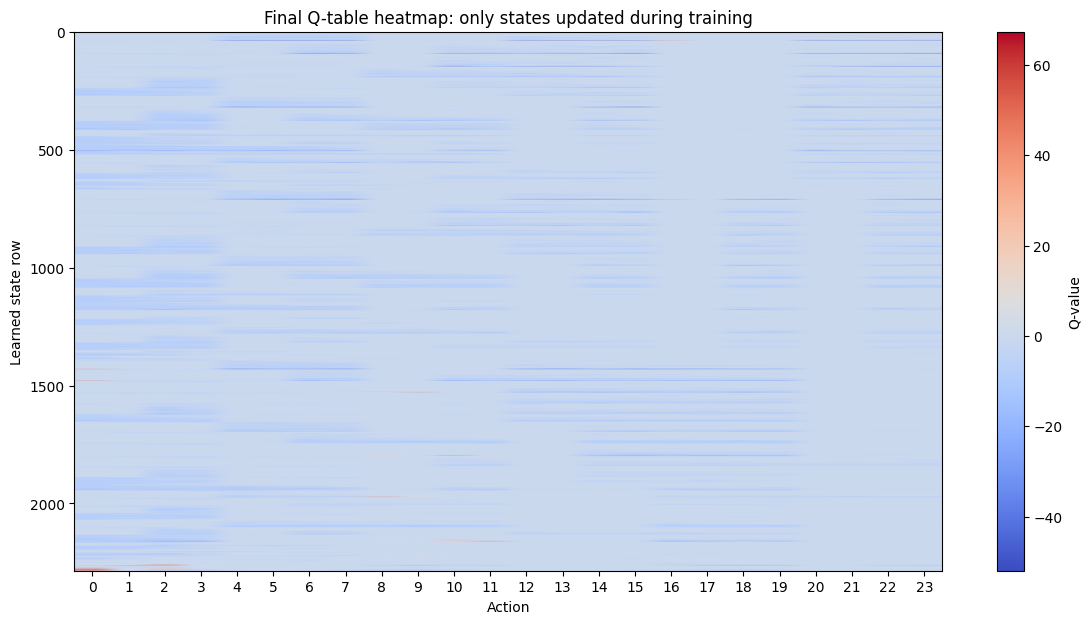

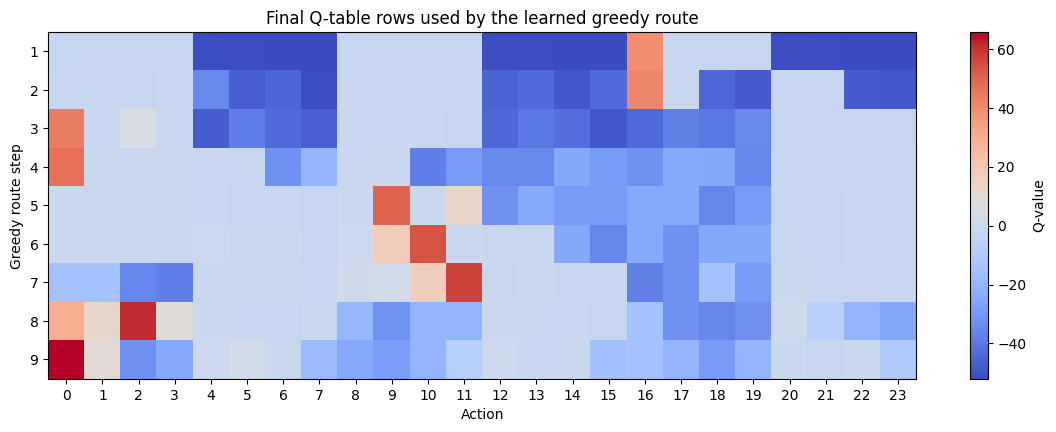

,step,position,0: +x 25%,1: +x 50%,2: +x 75%,3: +x 100%,4: -x 25%,5: -x 50%,6: -x 75%,7: -x 100%,...,14: -y 75%,15: -y 100%,16: +z 25%,17: +z 50%,18: +z 75%,19: +z 100%,20: -z 25%,21: -z 50%,22: -z 75%,23: -z 100%
0,1,"(0, 0, 1)",-1.872905,-1.879920,-1.902495,-1.933610,-51.249739,-51.497833,-51.749179,-51.999029,...,-51.748663,-51.999939,39.238319,-1.879046,-1.962567,-1.942605,-51.249778,-51.499183,-51.749863,-51.999029
1,2,"(0, 0, 2)",-1.716677,-1.766832,-1.866400,-1.835232,-35.160136,-46.655977,-44.817868,-51.250332,...,-48.370381,-43.714480,41.566652,-1.742968,-44.388989,-47.457581,-2.053453,-2.458876,-47.685742,-48.601818
2,3,"(1, 0, 2)",44.017528,-1.438063,4.034131,-1.571824,-47.229419,-37.830493,-43.506316,-46.152462,...,-41.963312,-48.601818,-43.960110,-37.466738,-39.763823,-35.329991,-2.053453,-2.144396,-2.467383,-2.497970
3,4,"(2, 0, 2)",47.123714,-0.854450,-1.002944,-0.929979,-1.728862,-1.390737,-32.543938,-20.258437,...,-24.975173,-29.205471,-32.232513,-24.855675,-24.975173,-35.669703,-1.528702,-2.081642,-2.289806,-1.433981
4,5,"(2, 1, 2)",-0.644101,-0.719313,-0.759171,-0.965218,-1.528702,-2.007814,-1.712839,-2.497970,...,-29.066397,-29.205471,-24.736177,-24.855675,-35.499847,-29.205471,-1.528702,-1.920958,-1.529810,-1.868551
5,6,"(2, 3, 2)",-0.547778,-0.756347,-0.936912,-0.612211,-0.337500,-1.390737,-0.763125,-1.868551,...,-24.975173,-35.669703,-24.736177,-32.388225,-24.975173,-25.094672,-1.251663,-1.920958,-1.712839,-1.868551
6,7,"(2, 5, 2)",-14.360625,-14.430000,-35.499847,-38.194247,-0.624375,-1.390737,-1.061156,-1.668884,...,-1.529810,-1.668884,-37.648615,-32.388225,-14.499375,-29.205471,-0.624375,-1.557126,-1.712839,-1.668884
7,8,"(4, 5, 2)",29.584813,12.168469,61.212500,8.372031,-0.765706,-1.698557,-1.868413,-0.832500,...,-1.529810,-1.868551,-14.360625,-32.388225,-35.499847,-32.699650,0.000000,-7.800000,-20.161969,-25.094672
8,9,"(5, 5, 2)",65.750000,9.525000,-32.232513,-24.855675,-0.337500,1.833483,-1.061156,-17.439814,...,-1.061156,-15.576251,-14.360625,-20.065500,-29.066397,-20.258437,-0.624375,-1.920958,-0.763125,-10.804500


In [18]:
import matplotlib.pyplot as plt

action_labels = [f"{i}: {spec['direction']} {spec['power']}" for i, spec in enumerate(training_env.action_table)]

# Plotting the entire Q-table is not very informative here. The table has 15,876
# encoded states, but training starts from one fixed start state, so many encoded position/battery/heading combinations are never visited and remain exactly zero.
# I summarize that sparsity first, then plot only rows where learning occurred.
learned_row_mask = np.any(np.abs(q_table) > 1e-9, axis=1)
learned_state_count = int(learned_row_mask.sum())
print(f"Total encoded states: {training_env.observation_space.n}")
print(f"States with at least one learned nonzero Q-value: {learned_state_count}")
print(f"Percent of encoded states updated: {learned_state_count / training_env.observation_space.n:.2%}")

learned_state_indices = np.flatnonzero(learned_row_mask)
learned_q_values = q_table[learned_state_indices]

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(learned_q_values, aspect="auto", cmap="coolwarm")
ax.set_title("Final Q-table heatmap: only states updated during training")
ax.set_xlabel("Action")
ax.set_ylabel("Learned state row")
ax.set_xticks(range(training_env.action_space.n), labels=range(training_env.action_space.n), rotation=0)
fig.colorbar(im, ax=ax, label="Q-value")
plt.show()

# This smaller heatmap is usually the clearest Q-table view because it shows the
# exact states used by the final greedy policy from the start to the goal.
route_states = greedy_route["state"].to_numpy(dtype=int)
route_q_values = q_table[route_states]

fig, ax = plt.subplots(figsize=(14, max(4, 0.5 * len(route_states))))
im = ax.imshow(route_q_values, aspect="auto", cmap="coolwarm")
ax.set_title("Final Q-table rows used by the learned greedy route")
ax.set_xlabel("Action")
ax.set_ylabel("Greedy route step")
ax.set_xticks(range(training_env.action_space.n), labels=range(training_env.action_space.n), rotation=0)
ax.set_yticks(range(len(route_states)), labels=greedy_route["step"])
fig.colorbar(im, ax=ax, label="Q-value")
plt.show()

route_action_values = pd.DataFrame(route_q_values, columns=action_labels)
route_action_values.insert(0, "step", greedy_route["step"].to_numpy())
route_action_values.insert(1, "position", greedy_route["position"].to_numpy())
route_action_values


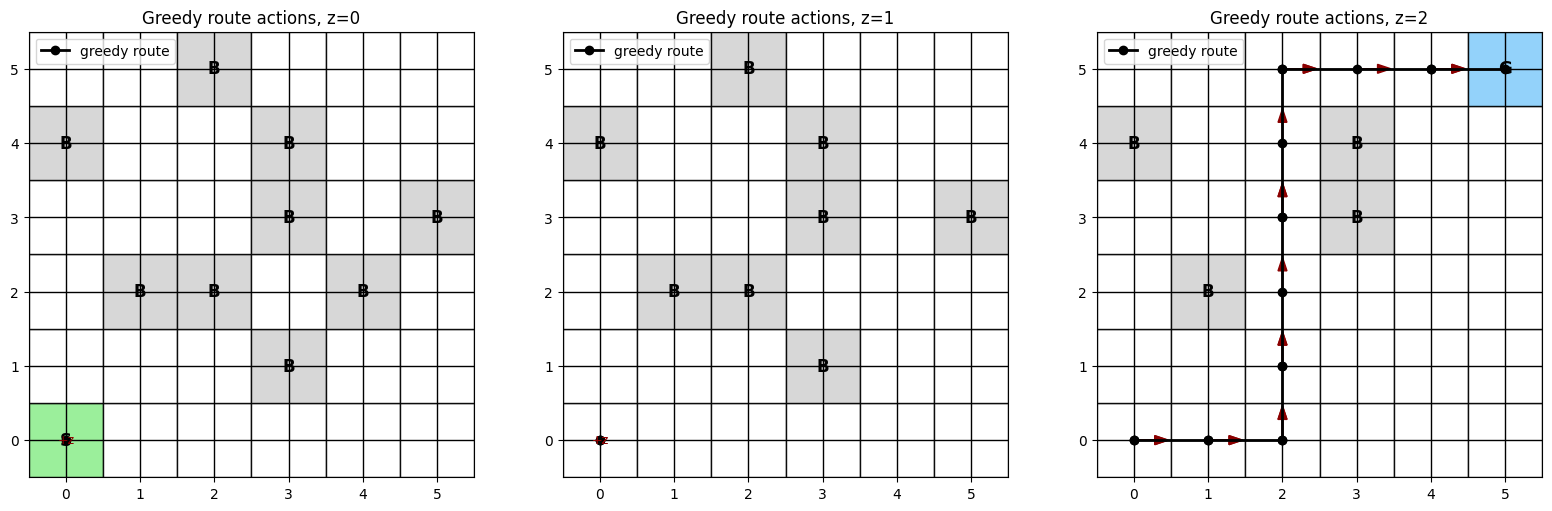

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def expand_greedy_route(env, greedy_route):
    """Return every crossed cell and the route action used from that cell.

    The greedy route table stores one row per action. Some actions move two grid
    cells, so this helper expands those actions into the intermediate cells that
    the drone crosses. This makes vertical moves through z=1 visible.
    """
    expanded = []
    current_position = env.start.copy()

    for _, row in greedy_route.iterrows():
        action = int(row["action"])
        action_spec = env.action_table[action]
        start_position = tuple(int(value) for value in current_position)
        expanded.append({"position": start_position, "action": action})

        for step in range(1, action_spec["distance"] + 1):
            crossed_position = current_position + action_spec["vector"] * step
            expanded.append({"position": tuple(int(value) for value in crossed_position), "action": action})

        current_position = np.array(expanded[-1]["position"], dtype=np.int64)

    return expanded


def draw_greedy_route_actions(env, greedy_route):
    """Draw only the final greedy route and the actions used along that route.
    """
    fig, axes = plt.subplots(1, env.height, figsize=(16, 5), constrained_layout=True)
    if env.height == 1:
        axes = [axes]

    expanded_route = expand_greedy_route(env, greedy_route)
    route_positions = [entry["position"] for entry in expanded_route]
    route_by_layer = {z: [] for z in range(env.height)}
    route_actions_by_position = {}

    for entry in expanded_route:
        position = entry["position"]
        route_by_layer[position[2]].append(position)
        route_actions_by_position[position] = entry["action"]

    for z, ax in enumerate(axes):
        ax.set_title(f"Greedy route actions, z={z}")
        ax.set_xlim(0, env.width)
        ax.set_ylim(0, env.depth)
        ax.set_aspect("equal")
        ax.set_xticks(np.arange(env.width) + 0.5, labels=range(env.width))
        ax.set_yticks(np.arange(env.depth) + 0.5, labels=range(env.depth))
        ax.grid(color="black", linewidth=1)

        for x in range(env.width):
            for y in range(env.depth):
                cell = (x, y, z)
                facecolor = "white"
                label = ""
                if cell in env.buildings:
                    facecolor = "lightgray"
                    label = "B"
                if cell == tuple(env.start):
                    facecolor = "lightgreen"
                    label = "S"
                if cell == tuple(env.goal):
                    facecolor = "lightskyblue"
                    label = "G"

                ax.add_patch(Rectangle((x, y), 1, 1, facecolor=facecolor, edgecolor="black", alpha=0.9))
                if label:
                    ax.text(x + 0.5, y + 0.5, label, ha="center", va="center", fontsize=12, weight="bold")

        if route_by_layer[z]:
            xs = [position[0] + 0.5 for position in route_by_layer[z]]
            ys = [position[1] + 0.5 for position in route_by_layer[z]]
            ax.plot(xs, ys, color="black", linewidth=2, marker="o", label="greedy route")
            ax.legend(loc="upper left")

        # Draw red action markers on greedy route cells.
        for position in route_by_layer[z]:
            if position == tuple(env.goal):
                continue
            action = route_actions_by_position[position]
            direction = env.action_table[action]["direction"]
            dx, dy = 0.0, 0.0
            text = ""
            if direction == "+x":
                dx = 0.28
            elif direction == "-x":
                dx = -0.28
            elif direction == "+y":
                dy = 0.28
            elif direction == "-y":
                dy = -0.28
            elif direction == "+z":
                text = "+z"
            elif direction == "-z":
                text = "-z"

            x, y, _ = position
            if text:
                ax.text(x + 0.5, y + 0.5, text, ha="center", va="center", fontsize=9, color="darkred")
            else:
                ax.arrow(x + 0.5, y + 0.5, dx, dy, head_width=0.12, color="darkred")

    return fig


policy_env = DroneDeliveryEnv()
draw_greedy_route_actions(policy_env, greedy_route)
plt.show()


### Part B Analysis

**1. What did the agent learn?**

The agent learned how to get the drone from the start location to the delivery location without crashing into buildings. The final greedy route is the most useful thing to look at here because it turns the Q-table back into something readable: position, action, battery, heading, and reward at each step. In the successful run, the route ends at `(5, 5, 2)`, which is the delivery target, and there is no crash reason listed. The training curves show that the agent starts out mostly crashing, which is why the reward is strongly negative and the episode length is short. Around episode 9000, the moving average reward jumps upward and the success rate rises sharply. This suggests the agent discovered a reliable delivery route. After that point, the curves flatten out, so the policy has mostly converged. The success rate does not reach 100% because epsilon-greedy exploration is still active during training, meaning the agent still takes some random actions even near the end. The final greedy-policy evaluation is a better measure of the learned policy, and that run reaches the goal successfully.

One important detail is that the learned route may not look like it visits every altitude layer. That is because some power settings move more than one grid cell at a time. So if the drone uses a stronger upward move, it can move from `z=0` to `z=2` in one action. The environment still checks the crossed path for collisions, but the printed route records the state after each action.

**2. How does the reward design affect convergence?**

The reward design is what tells the agent what I actually care about. I gave a large positive reward for reaching the goal, a large negative reward for crashing, and smaller penalties for time, energy use, and changing heading. That means the agent is pushed toward the behavior I want: deliver the package, do not crash, and do not waste battery or steps.

I do not think of these reward values as perfectly correct numbers. They are design choices. They are reasonable if they make the learned policy match the goal of the environment. In this case, the goal reward needs to be big enough to overcome the normal movement costs. The crash penalty needs to be large enough that the agent does not treat buildings as an acceptable shortcut. The smaller time and energy penalties keep the drone from wandering around when a shorter path is available.

The distance-shaping reward also matters. Without it, the agent would mostly receive bad rewards until it randomly found the goal. By giving a small reward for moving closer to the goal, the agent gets useful feedback earlier in training.

**3. If I adjusted gamma or epsilon, how did learning change?**

`gamma` controls how much the agent cares about future reward. Since the delivery reward is several moves away from the start, I need `gamma` to be fairly high. If `gamma` is too low, the agent focuses too much on the immediate step penalties and does not value the future delivery reward enough.

`epsilon` controls exploration. At the beginning, I want a high epsilon because the agent needs to try different actions and discover safe routes. Later on, I want epsilon to decay so the agent can use what it learned. If epsilon stays too high, the reward plot stays noisy because the agent keeps taking random actions, including crashes. If epsilon drops too quickly, the agent may settle on a bad route before it has explored enough.

**4. What are the failure modes?**

The biggest failure mode is crashing while exploring. This happens a lot early in training because high-power actions can cross multiple cells, and a single bad move can hit a building or leave the city airspace.

Another failure mode is poor exploration. If the agent does not explore enough, it may never find a successful delivery route. If the rewards are scaled badly, it could also learn the wrong behavior. For example, if the crash penalty were too small, the agent might not avoid buildings strongly enough. If the step penalty were too large compared with the goal reward, the agent might avoid moving because every move feels too expensive.

The environment could be made harder by adding more buildings, lowering the battery, adding random wind, or making the drone only partially observe the map. It could be made easier by using fewer buildings, giving the drone more battery, shrinking the grid, or giving stronger reward feedback for moving toward the goal.


# Q2 — Particle Swarm Optimization (PSO): From-Scratch + Validation 💡
 
## 35 points total

---

### Goals
- Implement PSO from the velocity/position update equations and design sane hyperparameters.  
- Analyze convergence behavior and sensitivity to parameters $\omega, c_1, c_2$.  
- Validate your implementation against a standard PSO library.  
- Reflect on hybridizing PSO with Genetic Algorithm (GA) operators (theory only).  

---

### Objective Function (Rastrigin)
Use the Rastrigin function in $\mathbb{R}^d$ with box constraints $x_i \in [-5.12, 5.12]$:

$$
f(x) = 10d + \sum_{i=1}^{d} \left( x_i^2 - 10\cos(2\pi x_i) \right), \quad d = 30
$$

Known global optimum: $f(0) = 0$.  
This function is multimodal and separable—an excellent stress test for balancing exploration vs. exploitation.  
(*Optional:* You may also report results for $d \in \{10, 50\}$ in an appendix.)

---

### [10 points] Part A — Implement PSO from Scratch 

Implement canonical PSO with inertia using the following update equations:

$$
v_i(t+1) = \omega v_i(t) + c_1 r_1 \odot (pbest_i - x_i(t)) + c_2 r_2 \odot (gbest - x_i(t))
$$
$$
x_i(t+1) = x_i(t) + v_i(t+1)
$$

where $r_1, r_2 \sim U[0,1]^d$.  
After each update, clip positions to the bounding box.  

**Required features:**
- **Initialization:** $N = 60$ particles uniformly in $[-5.12, 5.12]^d$; initial velocities $= 0$.  
- Track each particle's **pbest** and global **gbest**.  
- Implement **velocity clamping** (e.g., $\|v\|_\infty \le 0.2 \times \text{range}$) or a **constriction factor** $\chi$ (cite which you used).  
- **Stopping condition:** 10,000 function evaluations **or** $f(gbest) \le 10^{-6}$.  
- Choose one **inertia schedule**:
  - Fixed $\omega$ (e.g., 0.7) with fixed $c_1, c_2$, or  
  - Linear decay $\omega: 0.9 \to 0.4$ over iterations.  
- **Randomness:** seed your RNG; run 20 independent trials.  

**Suggested defaults:** $\omega = 0.7, \; c_1 = c_2 = 1.6, \; v_{max} = 1.0$ per coordinate.

---

### [10 points] Part B — Convergence & Sensitivity Analysis
- Run experiments to analyze the **convergence behavior** and **sensitivity** of your PSO to $\omega, c_1, c_2$.  
- Report and discuss how different parameter settings affect convergence speed and final accuracy.  
- Plot **best-so-far vs. function evaluations** (mean $\pm$ 95% CI) across 20 trials.  
- Discuss **exploration–exploitation trade-offs** observed in your runs.  

**Deliverables:**
- Parameter sweep summary (tables or plots).  
- Key insights about sensitivity and stability.  

---

### [10 points] Part C — Validation Against a PSO Library
Validate your implementation using a PSO package such as `pyswarms` (`pip install pyswarms`).  

Keep the same:
- $N, d, \omega, c_1, c_2,$ and bounds.  
- Objective function and stopping criteria.  

**Report:**
- Final best $f$ (mean $\pm$ std over 20 trials) for *Your PSO* vs. *Library PSO*.  
- Fraction of trials achieving $f \le 10^{-3}$ (reliability).  
- Comparative plots (best-so-far curves).  

---

### [5 points] Part D — Theoretical Reflection

Reflect on **how PSO could be hybridized with GA operators** (e.g., crossover or mutation).  
- What advantages might this bring?  
- What risks or implementation challenges could arise?  


<!-- codex-q2-start -->
## Q2 Response

I used the Module 10 PSO example as the template for this implementation. In particular, I followed the same structure from `Module_10_example/src/utils/psoAlgorithm.js`: initialize the swarm, evaluate particles, update velocities/positions, and run repeated PSO iterations. I also used the Rastrigin definition from `Module_10_example/src/utils/fitnessFunctions.js` as the reference, then expanded it from the 2D visualization version to the required `d = 30` version.

I kept this version in Python/NumPy. The code is still intentionally close to the Module 10 example, just vectorized for 60 particles in 30 dimensions.


### Part A - From-Scratch PSO

I am minimizing the 30-dimensional Rastrigin function. The global optimum is at the zero vector, where `f(x) = 0`. Since this function has many local minima, it is a good test of whether PSO balances exploration and exploitation.

For the required velocity control, I use **velocity clamping** with `vmax = 1.0` per coordinate. This is the same basic idea used in the Module 10 example, where velocity is clipped so particles do not jump too far in one update.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Required PSO setup from the prompt.
N_PARTICLES = 60
DIMENSIONS = 30
BOUNDS = (-5.12, 5.12)
MAX_EVALUATIONS = 10_000
TARGET_FITNESS = 1e-6
VMAX = 1.0
MAX_ITERATIONS = (MAX_EVALUATIONS - N_PARTICLES) // N_PARTICLES


def rastrigin(X):
    """Rastrigin objective in d dimensions.
    X is a matrix with shape (n_particles, dimensions). The return value is one
    fitness value per particle. Lower is better, and the best possible value is 0.
    """
    X = np.asarray(X, dtype=float)
    d = X.shape[1]
    return 10 * d + np.sum(X**2 - 10 * np.cos(2 * np.pi * X), axis=1)


def initialize_swarm(rng, n_particles=N_PARTICLES, dimensions=DIMENSIONS, bounds=BOUNDS):
    """Create particles, zero velocities, pbest, and gbest.
    This mirrors initializeSwarm from the Module 10 example, except the arrays are vectorized for 30 dimensions instead of using x/y fields for a 2D animation.
    """
    low, high = bounds
    positions = rng.uniform(low, high, size=(n_particles, dimensions))
    velocities = np.zeros_like(positions)
    fitness = rastrigin(positions)

    best_index = int(np.argmin(fitness))
    return {
        "positions": positions,
        "velocities": velocities,
        "fitness": fitness,
        "pbest_positions": positions.copy(),
        "pbest_fitness": fitness.copy(),
        "gbest_position": positions[best_index].copy(),
        "gbest_fitness": float(fitness[best_index]),
    }


def evaluate_swarm(swarm):
    """Update each particle's personal best and the swarm's global best."""
    fitness = rastrigin(swarm["positions"])
    improved = fitness < swarm["pbest_fitness"]

    swarm["fitness"] = fitness
    swarm["pbest_positions"][improved] = swarm["positions"][improved]
    swarm["pbest_fitness"][improved] = fitness[improved]

    best_index = int(np.argmin(swarm["pbest_fitness"]))
    if swarm["pbest_fitness"][best_index] < swarm["gbest_fitness"]:
        swarm["gbest_fitness"] = float(swarm["pbest_fitness"][best_index])
        swarm["gbest_position"] = swarm["pbest_positions"][best_index].copy()

    return swarm


def inertia_value(iteration, max_iterations, omega_start=0.9, omega_end=0.4):
    """Linearly decay inertia from omega_start to omega_end."""
    if max_iterations <= 1:
        return omega_end
    fraction = iteration / (max_iterations - 1)
    return omega_start + fraction * (omega_end - omega_start)


def update_swarm(swarm, rng, omega, c1, c2, bounds=BOUNDS, vmax=VMAX):
    """Apply the canonical PSO velocity and position updates.
    velocity = inertia + cognitive pull toward pbest + social pull toward gbest
    position = old position + updated velocity
    """
    low, high = bounds
    r1 = rng.random(swarm["positions"].shape)
    r2 = rng.random(swarm["positions"].shape)

    inertia = omega * swarm["velocities"]
    cognitive = c1 * r1 * (swarm["pbest_positions"] - swarm["positions"])
    social = c2 * r2 * (swarm["gbest_position"] - swarm["positions"])

    swarm["velocities"] = inertia + cognitive + social
    swarm["velocities"] = np.clip(swarm["velocities"], -vmax, vmax)
    swarm["positions"] = np.clip(swarm["positions"] + swarm["velocities"], low, high)
    return swarm


def run_pso_trial(
    seed,
    omega_start=0.9,
    omega_end=0.4,
    c1=1.6,
    c2=1.6,
    n_particles=N_PARTICLES,
    dimensions=DIMENSIONS,
    bounds=BOUNDS,
    vmax=VMAX,
    max_evaluations=MAX_EVALUATIONS,
    target_fitness=TARGET_FITNESS,
):
    """Run one seeded PSO trial and return the best result and history."""
    rng = np.random.default_rng(seed)
    swarm = initialize_swarm(rng, n_particles, dimensions, bounds)

    evaluations_used = n_particles
    max_iterations = (max_evaluations - n_particles) // n_particles
    best_history = [swarm["gbest_fitness"]]

    for iteration in range(max_iterations):
        omega = inertia_value(iteration, max_iterations, omega_start, omega_end)
        swarm = update_swarm(swarm, rng, omega, c1, c2, bounds, vmax)
        swarm = evaluate_swarm(swarm)
        evaluations_used += n_particles
        best_history.append(swarm["gbest_fitness"])

        if swarm["gbest_fitness"] <= target_fitness:
            break

    # Pad early-stopped runs so histories from different trials have same length.
    padded_history = np.full(max_iterations + 1, best_history[-1], dtype=float)
    padded_history[: len(best_history)] = best_history

    return {
        "best_fitness": swarm["gbest_fitness"],
        "best_position": swarm["gbest_position"],
        "history": padded_history,
        "evaluations_used": evaluations_used,
        "reliable_1e3": swarm["gbest_fitness"] <= 1e-3,
    }


def summarize_trials(results, label):
    """Summarize repeated PSO trials in a compact table row."""
    best_values = np.array([result["best_fitness"] for result in results], dtype=float)
    return {
        "setting": label,
        "mean_final_f": best_values.mean(),
        "std_final_f": best_values.std(ddof=1),
        "best_final_f": best_values.min(),
        "success_rate_f<=1e-3": np.mean([result["reliable_1e3"] for result in results]),
    }


def mean_and_95_ci(histories):
    """Return mean curve and 95% confidence interval across trials."""
    histories = np.asarray(histories, dtype=float)
    mean = histories.mean(axis=0)
    stderr = histories.std(axis=0, ddof=1) / np.sqrt(histories.shape[0])
    ci = 1.96 * stderr
    return mean, ci


In [21]:
BASELINE = {
    "omega_start": 0.9,
    "omega_end": 0.4,
    "c1": 1.6,
    "c2": 1.6,
}

baseline_results = [
    run_pso_trial(seed=2026 + 101 * trial, **BASELINE)
    for trial in range(20)
]

baseline_summary = pd.DataFrame([summarize_trials(baseline_results, "linear omega 0.9 -> 0.4, c1=c2=1.6")])
baseline_summary


,setting,mean_final_f,std_final_f,best_final_f,success_rate_f<=1e-3
0,"linear omega 0.9 -> 0.4, c1=c2=1.6",44.708661,10.951695,26.901659,0.0


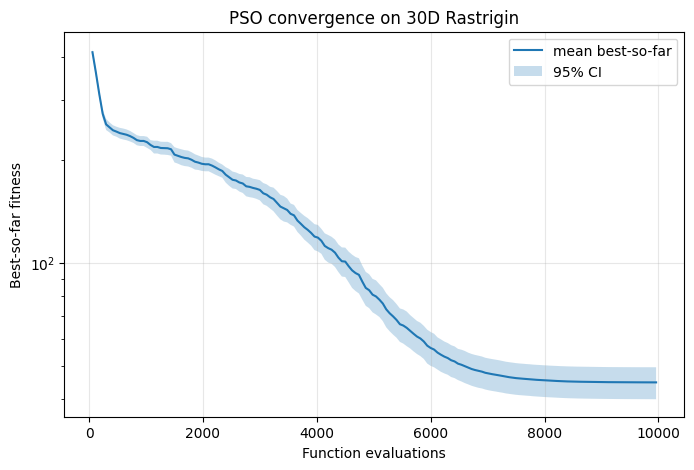

In [22]:
eval_axis = N_PARTICLES + np.arange(MAX_ITERATIONS + 1) * N_PARTICLES
baseline_histories = np.array([result["history"] for result in baseline_results])
baseline_mean, baseline_ci = mean_and_95_ci(baseline_histories)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eval_axis, baseline_mean, label="mean best-so-far")
ax.fill_between(eval_axis, baseline_mean - baseline_ci, baseline_mean + baseline_ci, alpha=0.25, label="95% CI")
ax.set_title("PSO convergence on 30D Rastrigin")
ax.set_xlabel("Function evaluations")
ax.set_ylabel("Best-so-far fitness")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### Part B - Convergence and Sensitivity

For the sensitivity check, I changed one broad behavior at a time. I kept the same number of particles, dimensions, bounds, and evaluation budget so the comparison is fair. I am mostly looking for whether the swarm improves smoothly or gets stuck with a worse final value.


In [23]:
sweep_settings = [
    {"label": "linear omega 0.9 -> 0.4, c1=c2=1.6", "omega_start": 0.9, "omega_end": 0.4, "c1": 1.6, "c2": 1.6},
    {"label": "fixed omega 0.7, c1=c2=1.6", "omega_start": 0.7, "omega_end": 0.7, "c1": 1.6, "c2": 1.6},
    {"label": "high fixed omega 0.9", "omega_start": 0.9, "omega_end": 0.9, "c1": 1.6, "c2": 1.6},
    {"label": "low social c2=0.8", "omega_start": 0.9, "omega_end": 0.4, "c1": 1.6, "c2": 0.8},
    {"label": "high social c2=2.2", "omega_start": 0.9, "omega_end": 0.4, "c1": 1.6, "c2": 2.2},
    {"label": "high cognitive c1=2.2", "omega_start": 0.9, "omega_end": 0.4, "c1": 2.2, "c2": 1.6},
]

sweep_results = {}
for setting_index, setting in enumerate(sweep_settings):
    label = setting["label"]
    params = {key: value for key, value in setting.items() if key != "label"}
    sweep_results[label] = [
        run_pso_trial(seed=5000 + 1000 * setting_index + 37 * trial, **params)
        for trial in range(20)
    ]

sweep_summary = pd.DataFrame([
    summarize_trials(results, label)
    for label, results in sweep_results.items()
]).sort_values("mean_final_f")

sweep_summary


,setting,mean_final_f,std_final_f,best_final_f,success_rate_f<=1e-3
1,"fixed omega 0.7, c1=c2=1.6",39.207008,11.181130,21.075374,0.0
3,low social c2=0.8,43.363126,14.695051,26.466740,0.0
5,high cognitive c1=2.2,47.240839,16.263643,19.489215,0.0
0,"linear omega 0.9 -> 0.4, c1=c2=1.6",47.682975,10.983217,26.091112,0.0
4,high social c2=2.2,48.043902,9.558283,27.081667,0.0
2,high fixed omega 0.9,184.687866,15.984666,157.616484,0.0


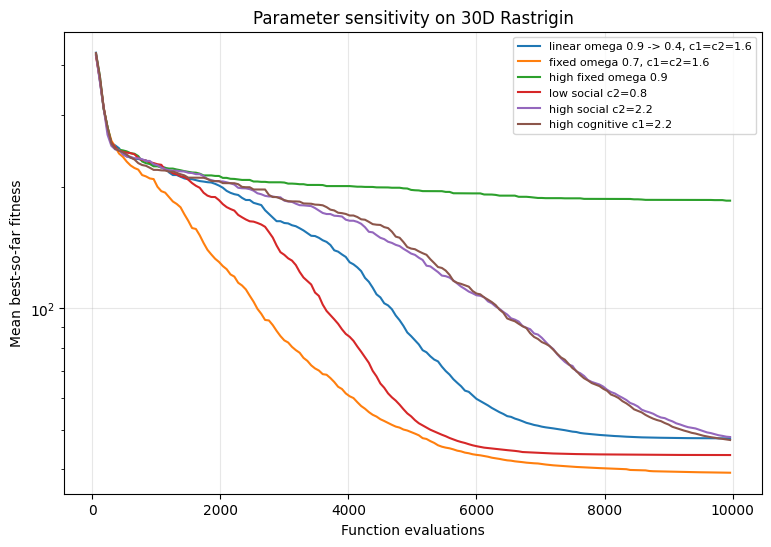

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

for label, results in sweep_results.items():
    histories = np.array([result["history"] for result in results])
    mean_curve, _ = mean_and_95_ci(histories)
    ax.plot(eval_axis, mean_curve, label=label)

ax.set_title("Parameter sensitivity on 30D Rastrigin")
ax.set_xlabel("Function evaluations")
ax.set_ylabel("Mean best-so-far fitness")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()


### Part C - Validation Against `pyswarms`

For validation, I compare my implementation against `pyswarms.single.GlobalBestPSO`. I keep the same objective, number of particles, dimension, bounds, `c1`, `c2`, fixed `omega = 0.7`, velocity clamp, and iteration budget. I use fixed `omega = 0.7` here because that maps directly to the library options.


In [25]:
from pyswarms.single import GlobalBestPSO


def run_library_trial(seed, n_particles=N_PARTICLES, dimensions=DIMENSIONS, bounds=BOUNDS, max_iterations=MAX_ITERATIONS):
    """Run one comparable GlobalBestPSO trial from pyswarms."""
    rng = np.random.default_rng(seed)
    init_pos = rng.uniform(bounds[0], bounds[1], size=(n_particles, dimensions))

    optimizer = GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options={"c1": 1.6, "c2": 1.6, "w": 0.7},
        bounds=(np.full(dimensions, bounds[0]), np.full(dimensions, bounds[1])),
        velocity_clamp=(-VMAX, VMAX),
        init_pos=init_pos,
    )

    # Match the assignment requirement that initial velocities start at zero.
    optimizer.swarm.velocity[:] = 0.0
    best_fitness, best_position = optimizer.optimize(rastrigin, iters=max_iterations, verbose=False)

    history = np.array(optimizer.cost_history, dtype=float)
    padded_history = np.full(MAX_ITERATIONS + 1, history[-1], dtype=float)
    padded_history[: len(history)] = history

    return {
        "best_fitness": float(best_fitness),
        "best_position": best_position,
        "history": padded_history,
        "evaluations_used": n_particles * len(history),
        "reliable_1e3": float(best_fitness) <= 1e-3,
    }


my_fixed_results = [
    run_pso_trial(seed=8000 + 43 * trial, omega_start=0.7, omega_end=0.7, c1=1.6, c2=1.6)
    for trial in range(20)
]
library_results = [
    run_library_trial(seed=8000 + 43 * trial)
    for trial in range(20)
]

validation_summary = pd.DataFrame([
    summarize_trials(my_fixed_results, "My PSO"),
    summarize_trials(library_results, "pyswarms GlobalBestPSO"),
])
validation_summary


,setting,mean_final_f,std_final_f,best_final_f,success_rate_f<=1e-3
0,My PSO,41.291418,11.342825,23.711858,0.0
1,pyswarms GlobalBestPSO,45.131535,10.300597,30.128529,0.0


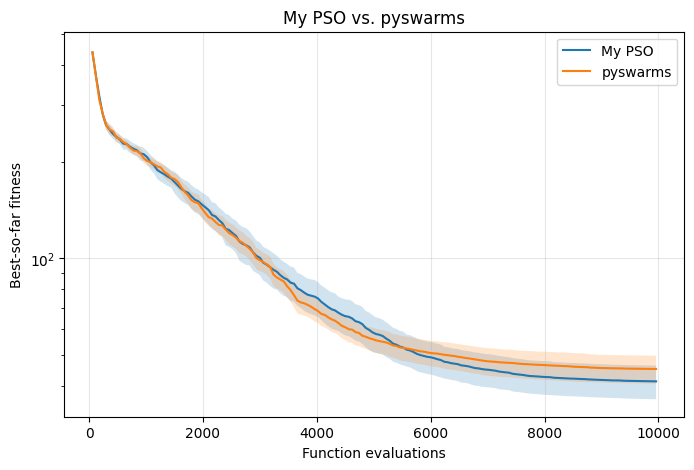

In [26]:
my_mean, my_ci = mean_and_95_ci([result["history"] for result in my_fixed_results])
lib_mean, lib_ci = mean_and_95_ci([result["history"] for result in library_results])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eval_axis, my_mean, label="My PSO")
ax.fill_between(eval_axis, my_mean - my_ci, my_mean + my_ci, alpha=0.20)
ax.plot(eval_axis, lib_mean, label="pyswarms")
ax.fill_between(eval_axis, lib_mean - lib_ci, lib_mean + lib_ci, alpha=0.20)
ax.set_title("My PSO vs. pyswarms")
ax.set_xlabel("Function evaluations")
ax.set_ylabel("Best-so-far fitness")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


### Q2 Analysis

**Part A.** I implemented the PSO loop using the same structure as the Module 10 example: initialize the swarm, evaluate fitness, update personal/global bests, then update velocity and position. The main change is that this homework version is 30-dimensional and vectorized with NumPy arrays instead of using the 2D `x` and `y` particle structure from the visualization example. I also used velocity clamping with `vmax = 1.0` so particles cannot make extremely large jumps across the search space.

**Part B.** In the baseline run with linear inertia from `0.9` to `0.4` and `c1=c2=1.6`, the mean final fitness is about `44.71`, with the best trial reaching about `26.90`. The convergence plot drops quickly at the start and then flattens out. That tells me the swarm is finding better regions early, but it is not getting close to the true Rastrigin optimum of `0` within the `10,000` function-evaluation budget.

The parameter sweep gives a clearer result. The best average setting in my runs is `fixed omega 0.7, c1=c2=1.6`, with mean final fitness about `39.21`. The low social setting `c2=0.8` is next at about `43.36`. The worst setting is clearly `high fixed omega 0.9`, with mean final fitness about `184.69`, which is much worse than the other settings. This makes sense because the high fixed inertia keeps particles moving too strongly and makes it harder for the swarm to settle into good minima. None of the settings reach `f <= 1e-3`, so the success rate is `0.0` for every sweep row. For this assignment, the important comparison is the relative final fitness, not whether the optimizer solves 30D Rastrigin perfectly.

**Part C.** The library comparison is close enough to validate my implementation. With fixed `omega = 0.7`, my PSO gets mean final fitness about `41.29`, while `pyswarms` gets about `45.13`. My best trial is about `23.71`, and the library best trial is about `30.13`. Both methods also have `0.0` success rate for `f <= 1e-3`. Since the curves and final values are in the same range, I am confident my implementation is behaving like a normal global-best PSO, even though the exact results are not identical. I observed the library scores beating my implementation in prior runs but still within the same score delta.

**Part D.** PSO could be hybridized with GA operators by occasionally applying mutation or crossover to particle positions. Based on these results, I would especially consider mutation when the best-so-far curve has flattened out, because that is where the swarm seems to get stuck in local minima. Mutation could push some particles into new regions of the Rastrigin landscape, while crossover could combine useful coordinates from stronger particles. I would use these operators sparingly because too much random disruption would fight against the swarm memory that makes PSO useful.


# Q3 — Explore $\beta$-VAE Trade-offs with KL Diagnostics on MNIST

## 35 points total

### Objective

Variational Autoencoders (VAEs) introduce a probabilistic latent space for generative modeling. Compared to a Vanilla Autoencoder, which only learns to reconstruct inputs, VAEs and $\beta$-VAEs learn a probabilistic latent space that supports sampling and generation. A $\beta$-VAE (beta-Variational Autoencoder) extends the standard VAE by introducing a weighting factor $\beta$ (hyperparameter) on the Kullback–Leibler (KL)-divergence term in the ELBO objective to balance reconstruction quality and latent regularization. 

$\mathcal{L}_{\beta\text{-VAE}} = \mathbb{E}_{q_\phi(z|x)}[-\log p_\theta(x|z)] + \beta \cdot \text{KL}(q_\phi(z|x) \parallel p(z))$

Increasing $\beta$ encourages more disentangled and interpretable latent features but can reduce reconstruction accuracy, revealing a key trade-off between structure and fidelity.

You will train a $\beta$-VAE with a convolutional encoder/decoder on MNIST, test some $\beta$ values, and compare their effects through plots and visuals.

### [5 points] Part A – Prepare Data

__Goal:__ Prepare the MNIST dataset for input to a convolutional $\beta$-VAE. Ensure all images are correctly normalized and shaped for a ConvNet-based model.

1. Use the MNIST handwritten digit dataset via ```torchvision.datasets.MNIST```.
2. Apply the following transformation via ```transforms.ToTensor()```
   - Normalize pixel values to the $[0,1]$ range. 
   - Reshape to (1, 28, 28) and treat as a single-channel grayscale image.
3. Verify image shape. 
4. (Optional) Use a subset of 10,000–20,000 samples from the training set to reduce training time.


### [10 points] Part B – Set up a $\beta$-VAE with a Convolutional Architecture

__Goal:__ Implement a convolutional $\beta$-VAE architecture suitable for MNIST. Understand how the encoder, decoder, and loss function interact in variational generative modeling.

Use the following convolutional architecture:
- **Encoder**: Fully connected layers that map input 28×28 pixels to a latent Gaussian distribution  
Conv2d $\rightarrow$ ReLU $\rightarrow$ Conv2d $\rightarrow$ ReLU $\rightarrow$ Flatten $\rightarrow$ FC layers to produce $\mu$ (mean of latent distribution) and $\log{\sigma^2}$ (log-variance of latent distribution)
- **Decoder**: Maps $z$ back to 28×28 pixels using a sigmoid output layer  
FC $\rightarrow$ Unflatten $\rightarrow$ ConvTranspose2d $\rightarrow$ ReLU $\rightarrow$ ConvTranspose2d $\rightarrow$ Sigmoid, that output should be a reconstructed image of (1, 28, 28)
- **Latent Prior**:  Use a smaller latent dimension (e.g., 2) if you wish to visualize the latent space; otherwise, use 10.
- **Loss**: Use binary cross-entropy (BCE) reconstruction loss and KL divergence  

$$
\mathcal{L}_{\beta\text{-VAE}} = \text{BCE}(x, \hat{x}) + \beta \cdot \text{KL}(q(z|x) \parallel \mathcal{N}(0, I)) \\
, \text{where  } z = \mu + \sigma \cdot \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
$$



### [10 points] Part C – Train β-VAE and Track Loss


__Goal:__ Train the model using different $\beta$ values and observe their effect on the balance between reconstruction and KL divergence.

- Choose at least two $\beta$ values greater than 0 (e.g., $\beta \in \{0.5, 1, 4\}$) or try linearly increasing values.
- Train for 10–15 epochs per setting.
- Use ```latent_dim = 10```
- Use Adam Optimizer (learning rate $lr = 1e‑3$, batch size = 128).
- For each epoch, log and print the following:
  - Total loss
  - Reconstruction loss (BCE)
  - KL divergence
- (Optional) Save trained model weights and per-epoch metrics for visualization in Part D.


### [10 points] Part D – Visualize and Interpret

__Goal:__ Assess how $\beta$ influences model performance in terms of reconstruction fidelity and sample quality.

1. For each trained model (for each $\beta$), do the following: 
   - Pick 5 test-set images and show original vs. reconstructed side-by-side.
   - Sample 5 random latent vectors from \( \mathcal{N}(0, I) \), decode them, and show the generated outputs.
2. Reflect on your results - the observed impact of $\beta$ on learning dynamics, reconstruction, and generative quality.
   - Which $\beta$ gives better reconstructions? Which gives more diverse or sharper samples?
   - How does increasing $\beta$ affect the KL divergence and reconstruction error?
   - Do you observe KL → 0 (posterior collapse)?
   - What are the risks of using too small or too large a $\beta$?

## Q3 Response

- First lets start by defining what each portion of the objective function is and how B-VAE works
- Objective function: $\mathcal{L}_{\beta\text{-VAE}} = \mathbb{E}_{q_\phi(z|x)}[-\log p_\theta(x|z)] + \beta \cdot \text{KL}(q_\phi(z|x) \parallel p(z))$

1. $q_\phi(z|x)$ --> Encoder (inference model)
    - This is a neural network that maps input x to a distibution over latent variables z (remember that the latent variables are probabilistic not deterministic)
    - parametrized by weights $phi$
    - Typically outputs: mean μ(x) and variance σ²(x)
    - Each input is mapped to a distribution, not a single point
2. $p_\theta(x|z)$ --> Decoder
    - neural network that maps latent z to a distribution over output x
    - parametrized by $theta$
    - responsible for reconstructing the input
3. $ \mathbb{E}_{q_\phi(z|x)}[-\log p_\theta(x|z)]$ --> Reconstruction loss
    - Sample z from encoder
    - Decode back to x
    - Measure reconstruction error
    - Mean Squared Error (Gaussian assumption) or Binary Cross Entropy (Bernoulli assumption)
    - "How well can I reconstruct the input?"
4. $ \mathrm{KL}(q_\phi(z|x) \parallel p(z))$ --> Divergence term
    - Measures difference between:
        - Encoder distribution q(z|x)
        - Prior p(z)
    - Purpose:
        - Forces latent space to match a simple distribution
        - Enables smooth sampling and interpolation
5. $ p(z) = \mathcal{N}(0, I)$ --> prior
    - Easy to sample from
    - Encourages structured latent space
6. B --> Controls strength of KL regularization
    - Standard VAE: B = 1
    - B-VAE: B > 1
    - Higher B:
        - Stronger regularization
        - More structured / disentangled latent space
        - Worse reconstruction
    - Lower B:
        - Better reconstruction
        - Less structured latent space

KL divergence tells me how different the encoder's latent distribution is from the simple normal distribution I want it to stay near. In this B-VAE, the reconstruction loss asks, "can I rebuild the digit well?" and the KL term asks, "is my latent space still organized like `N(0, I)`?"

A low KL value means the latent distribution is close to the standard normal prior. A higher KL value means the encoder is using the latent space more freely. The B value controls how hard I punish that difference: larger B pushes the latent space toward `N(0, I)` more strongly, but it can make reconstructions worse.


### Part A - Prepare Data

In [27]:
# Remember that convolution is a way of sliding a small filter across an input and computing a weighted sum at each location.
# This is how edges and other features are detected and feature-binned depending on the kernel used.

# I am drawing from the official PyTorch examples:
# Convolution NN on MNIST: https://github.com/pytorch/examples/blob/main/mnist/main.py
# VAE using MNIST: https://github.com/pytorch/examples/blob/main/vae/main.py

# Important notebook note:
# The PyTorch examples are written like command-line scripts and use argparse.parse_args().
# In Jupyter, the kernel itself passes arguments such as --f=/path/to/kernel.json.
# If I call parse_args() directly, argparse tries to parse that Jupyter argument and crashes.
# So for the notebook version, I set the same configuration values directly.

from types import SimpleNamespace
from pathlib import Path
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms

args = SimpleNamespace(
    batch_size=128,
    epochs=10,
    no_accel=False,
    seed=1,
    log_interval=10,
)

if torch.cuda.is_available() and not args.no_accel:
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available() and not args.no_accel:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.manual_seed(args.seed)
print(f"Using device: {device}")

kwargs = {"num_workers": 1, "pin_memory": True} if device.type == "cuda" else {}
DATA_ROOT = Path("homework/datasets")

# Training data. ToTensor() gives shape (1, 28, 28) and scales pixels to [0, 1].
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        DATA_ROOT,
        train=True,
        download=True,
        transform=transforms.ToTensor(),
    ),
    batch_size=args.batch_size,
    shuffle=True,
    **kwargs,
)

# Test data.
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        DATA_ROOT,
        train=False,
        download=True,
        transform=transforms.ToTensor(),
    ),
    batch_size=args.batch_size,
    shuffle=False,
    **kwargs,
)

# Confirm this gives the shape and normalization needed for a ConvNet-based VAE.
images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Pixel range: min={images.min().item():.3f}, max={images.max().item():.3f}")


Using device: cuda
Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])
Pixel range: min=0.000, max=1.000


### Part B - Set up a B-VAE with a Convolutional Architecture

In [28]:


class BetaVAE(nn.Module):
    # Default of R10 for latent space
    def __init__(self, latent_dim=10):
        super(BetaVAE, self).__init__()
         # Encoder:
        # Input MNIST image shape: (batch, 1, 28, 28)
        
        # Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        # turns (1, 28, 28) into (32, 14, 14)
        
        # Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        # turns (32, 14, 14) into (64, 7, 7)
        
        # So after the conv layers, each image is represented by:
        # 64 * 7 * 7 = 3136 features
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        # If latent_dim = 10, then both outputs have shape:
        # (batch, 10)
        # These will be learned
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
       
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
        # Decoder:
        # Start from z with shape (batch, latent_dim).
        # First map it back up to 3136 features.
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)

        # Then reshape 3136 back into image-like feature maps:
        # (batch, 64, 7, 7)
        
        # ConvTranspose2d reverses the downsampling:
        # (64, 7, 7) -> (32, 14, 14)
        # (32, 14, 14) -> (1, 28, 28)
    
        # Sigmoid at the end keeps output pixels in [0, 1],
        # matching transforms.ToTensor() for MNIST.
        self.decoder = nn.Sequential(
            nn.Unflatten(dim=1, unflattened_size=(64, 7, 7)),
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4,  stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=4,
            stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        """ x: (batch, 1, 28, 28)
            mu/logvar: (batch, latent_dim)
        """
        features = self.encoder(x)
        mu = self.fc_mu(features)
        logvar = self.fc_logvar(features)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """
            Sample z = mu + std * epsilon where epsilon is 0-centered Normal
        """
        # With log rules, convert to std deviation
        std = torch.exp(0.5 * logvar)
        # random noise for sampling
        epsilon = torch.randn_like(std)
        return mu + std * epsilon
    
    def decode(self, z):
        """ z: (batch, latent_dim)
            reconstruction: (batch, 1, 28, 28)
        """
        features = self.decoder_input(z)
        return self.decoder(features)
    
    def forward(self, x):
        """ Full forward path. 
            To be used in training.
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar
    
    @staticmethod
    def beta_vae_loss(reconstruction, x, mu, logvar, beta):
        """ Loss function using beta hyperparameter + KL divergence. """
        # BCE measures reconstruction quality.
        bce = F.binary_cross_entropy(reconstruction, x, reduction="sum")

        # KL pushes q(z|x) = N(mu, sigma^2) toward the prior N(0, I).
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        # beta controls how strongly to regularize the latent space.
        total_loss = bce + beta * kld

        return total_loss, bce, kld


In [29]:
# Additional shape checks
latent_dim = 10
model = BetaVAE(latent_dim=latent_dim).to(device)

images, labels = next(iter(train_loader))
images = images.to(device)

reconstruction, mu, logvar = model(images)

print("Input shape:         ", images.shape)
print("Reconstruction shape:", reconstruction.shape)
print("mu shape:            ", mu.shape)
print("logvar shape:        ", logvar.shape)


Input shape:          torch.Size([128, 1, 28, 28])
Reconstruction shape: torch.Size([128, 1, 28, 28])
mu shape:             torch.Size([128, 10])
logvar shape:         torch.Size([128, 10])


<!-- codex-hw4-q3-part-c-start -->
### Part C - Train B-VAE and Track Loss
I track three values each epoch:

- **Total loss** = BCE + B × KL
- **Reconstruction loss / BCE** = how well the output image matches the input
- **KL divergence** = how strongly the latent distribution is being pushed toward `N(0, I)`

I use a subset of the MNIST training data to keep the notebook practical to run while still showing the trade-off clearly.


In [30]:
from torch.utils.data import DataLoader, Subset
import pandas as pd

# Settings
latent_dim = 10
beta_values = [0.5, 1.0, 4.0]
epochs_per_beta = args.epochs
learning_rate = 1e-3
train_subset_size = 10_000

# Use a fixed subset so beta comparisons use the same training examples.
generator = torch.Generator().manual_seed(args.seed)
subset_indices = torch.randperm(len(train_loader.dataset), generator=generator)[:train_subset_size]
train_subset = Subset(train_loader.dataset, subset_indices)
train_subset_loader = DataLoader(
    train_subset,
    batch_size=args.batch_size,
    shuffle=True,
    **kwargs,
)


def train_one_beta(beta, epochs=epochs_per_beta):
    """Train one B-VAE model and return the model plus per-epoch metrics."""
    model = BetaVAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    rows = []

    print(f"\nTraining beta={beta}")
    print(f"{'epoch':>5}  {'total':>10}  {'BCE':>10}  {'KL':>10}")
    print("-" * 43)

    for epoch in range(1, epochs + 1):
        # Set into training mode
        model.train()
        total_loss_sum = 0.0
        bce_sum = 0.0
        kld_sum = 0.0
        sample_count = 0

        for images, _ in train_subset_loader:
            images = images.to(device)
            # Reset gradients for pass
            optimizer.zero_grad()

            reconstruction, mu, logvar = model(images)
            loss, bce, kld = model.beta_vae_loss(reconstruction, images, mu, logvar, beta)

            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            total_loss_sum += loss.item()
            bce_sum += bce.item()
            kld_sum += kld.item()
            sample_count += batch_size

        # Normalize by sample count so beta runs are easier to compare.
        avg_total = total_loss_sum / sample_count
        avg_bce = bce_sum / sample_count
        avg_kld = kld_sum / sample_count

        rows.append({
            "beta": beta,
            "epoch": epoch,
            "total_loss": avg_total,
            "reconstruction_bce": avg_bce,
            "kl_divergence": avg_kld,
        })

        print(f"{epoch:5d}  {avg_total:10.2f}  {avg_bce:10.2f}  {avg_kld:10.2f}")

    return model, pd.DataFrame(rows)


trained_models = {}
metrics_frames = []

for beta in beta_values:
    model, metrics = train_one_beta(beta)
    trained_models[beta] = model
    metrics_frames.append(metrics)

training_metrics = pd.concat(metrics_frames, ignore_index=True)
training_metrics.tail()



Training beta=0.5
epoch       total         BCE          KL
-------------------------------------------
    1      237.19      225.85       22.69
    2      151.76      140.79       21.94
    3      132.28      120.95       22.67
    4      124.64      113.18       22.93
    5      119.84      108.30       23.07
    6      116.53      104.93       23.20
    7      114.11      102.46       23.29
    8      112.22      100.61       23.24
    9      110.72       99.07       23.30
   10      109.50       97.79       23.42

Training beta=1.0
epoch       total         BCE          KL
-------------------------------------------
    1      261.77      246.19       15.58
    2      161.10      145.28       15.82
    3      142.42      125.24       17.19
    4      135.46      117.82       17.64
    5      131.12      113.30       17.82
    6      127.98      109.78       18.19
    7      125.48      107.15       18.33
    8      123.45      104.97       18.48
    9      121.67      103.17     

,beta,epoch,total_loss,reconstruction_bce,kl_divergence
25,4.0,6,164.385201,131.163915,8.305321
26,4.0,7,161.997697,128.619642,8.344514
27,4.0,8,160.191376,126.347835,8.460885
28,4.0,9,158.746247,124.567910,8.544585
29,4.0,10,157.531501,123.121907,8.602399


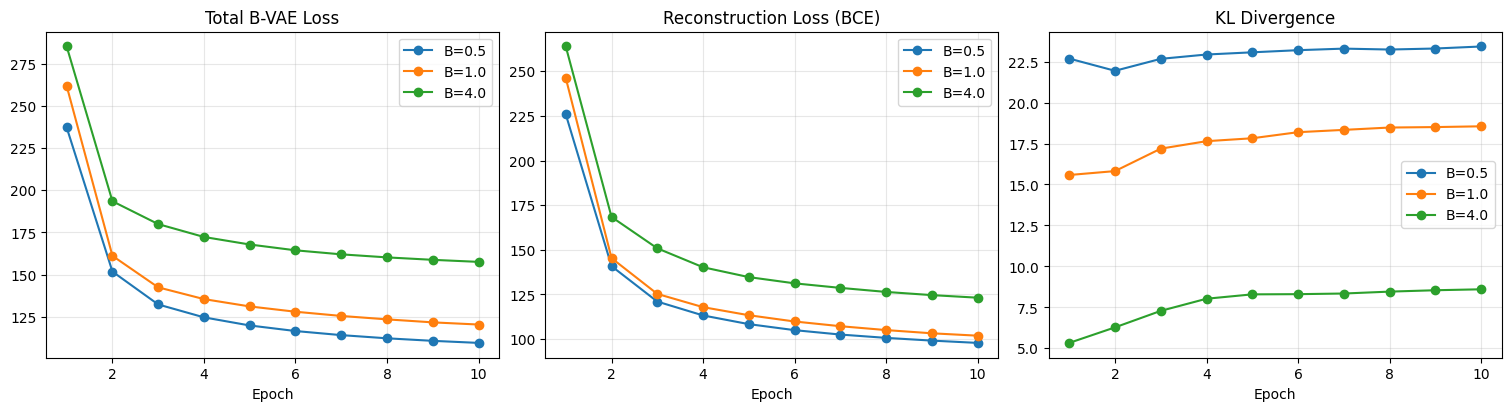

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

for beta in beta_values:
    beta_metrics = training_metrics[training_metrics["beta"] == beta]
    axes[0].plot(beta_metrics["epoch"], beta_metrics["total_loss"], marker="o", label=f"B={beta}")
    axes[1].plot(beta_metrics["epoch"], beta_metrics["reconstruction_bce"], marker="o", label=f"B={beta}")
    axes[2].plot(beta_metrics["epoch"], beta_metrics["kl_divergence"], marker="o", label=f"B={beta}")

axes[0].set_title("Total B-VAE Loss")
axes[1].set_title("Reconstruction Loss (BCE)")
axes[2].set_title("KL Divergence")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.show()


In [32]:
# Final-epoch comparison table.
final_metrics = (
    training_metrics
    .sort_values("epoch")
    .groupby("beta")
    .tail(1)
    .reset_index(drop=True)
)

final_metrics[["beta", "total_loss", "reconstruction_bce", "kl_divergence"]].round(2)


,beta,total_loss,reconstruction_bce,kl_divergence
0,0.5,109.50,97.79,23.42
1,1.0,120.39,101.83,18.55
2,4.0,157.53,123.12,8.60


<!-- codex-hw4-q3-part-d-start -->
### Part D - Visualize and Interpret

For this part, I compare the trained B-VAE models in two ways. First, I pass the same five MNIST test images through each model so I can compare the original images with their reconstructions. Second, I sample random latent vectors from `N(0, I)` and decode them to see what each model generates from the prior.


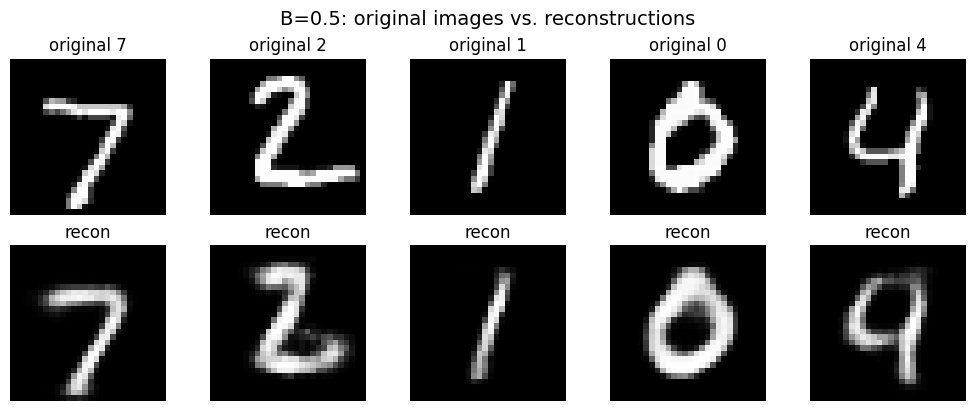

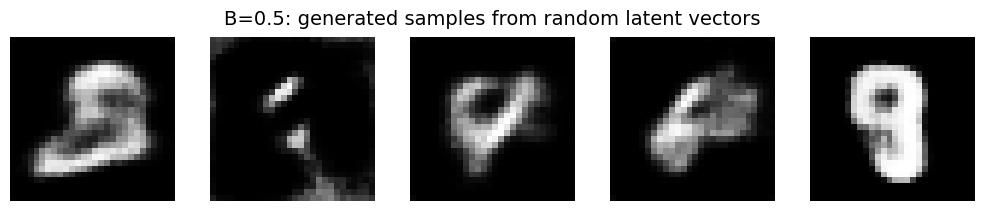

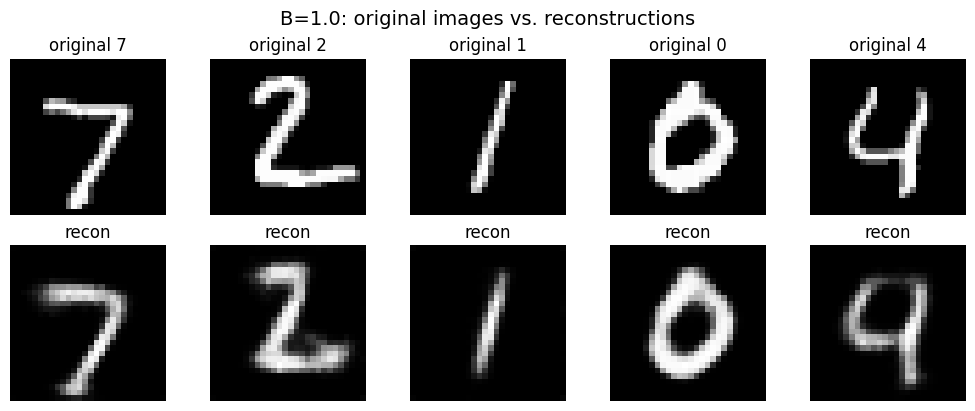

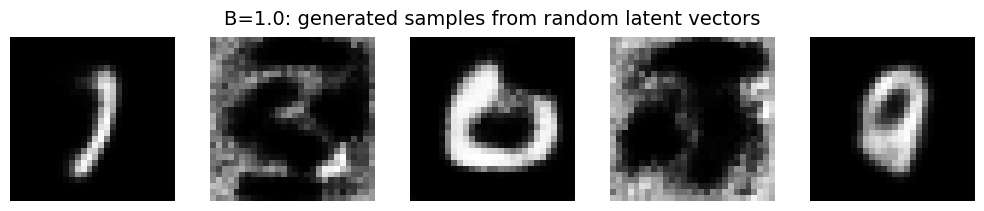

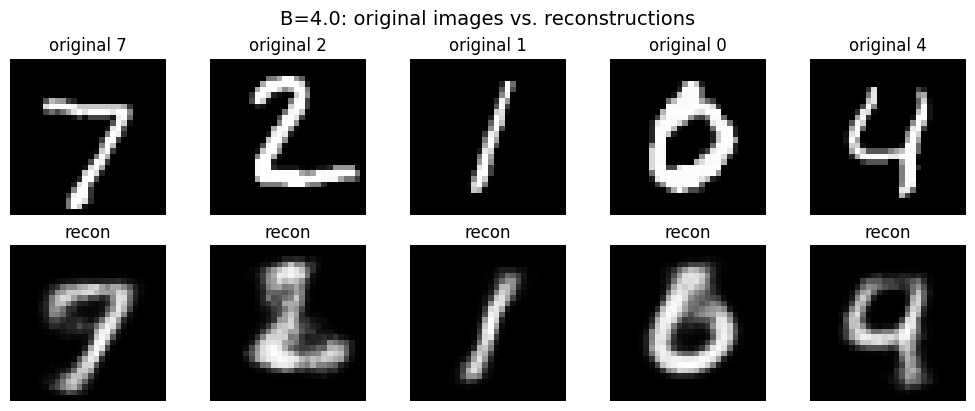

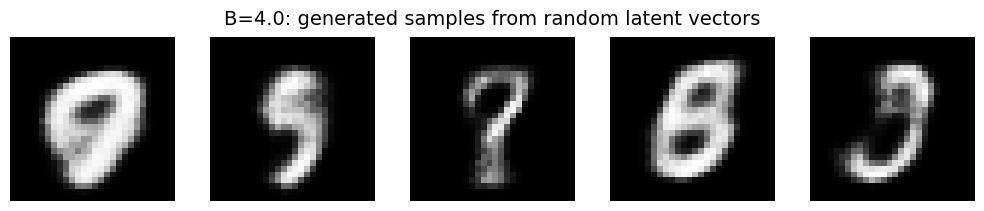

In [33]:
# Pick the same 5 test images for every beta model.
# This makes the reconstruction comparison fair because each model sees the same inputs.
test_images, test_labels = next(iter(test_loader))
comparison_images = test_images[:5].to(device)
comparison_labels = test_labels[:5]


def show_reconstructions(beta, model, images):
    """Show original images on top and reconstructed images on bottom for one beta value."""
    model.eval()
    with torch.no_grad():
        reconstructions, _, _ = model(images)

    fig, axes = plt.subplots(2, 5, figsize=(10, 4), constrained_layout=True)
    fig.suptitle(f"B={beta}: original images vs. reconstructions", fontsize=14)

    for col in range(5):
        axes[0, col].imshow(images[col].detach().cpu().squeeze(), cmap="gray")
        axes[0, col].set_title(f"original {comparison_labels[col].item()}")
        axes[0, col].axis("off")

        axes[1, col].imshow(reconstructions[col].detach().cpu().squeeze(), cmap="gray")
        axes[1, col].set_title("recon")
        axes[1, col].axis("off")

    plt.show()


def show_generated_samples(beta, model, sample_count=5):
    """Decode random z values sampled from N(0, I) for one beta value."""
    model.eval()
    with torch.no_grad():
        z = torch.randn(sample_count, latent_dim, device=device)
        generated = model.decode(z)

    fig, axes = plt.subplots(1, sample_count, figsize=(10, 2), constrained_layout=True)
    fig.suptitle(f"B={beta}: generated samples from random latent vectors", fontsize=14)

    for col in range(sample_count):
        axes[col].imshow(generated[col].detach().cpu().squeeze(), cmap="gray")
        axes[col].axis("off")

    plt.show()


# Run the visual comparison for each trained beta model.
torch.manual_seed(args.seed)
for beta in beta_values:
    show_reconstructions(beta, trained_models[beta], comparison_images)
    show_generated_samples(beta, trained_models[beta])


### Part D Interpretation

Looking at the reconstruction rows first, all three B values are able to rebuild the test digits in a recognizable way. The `7`, `1`, `0`, and `4` keep their main shape across the models. The `2` is the weakest reconstruction in all three cases because the bottom stroke gets blurred and the digit starts looking less clean than the original. Overall, B=0.5 and B=1.0 look very similar visually, which matches the training table where their reconstruction BCE values are close. B=4.0 still reconstructs the digits, but the outputs look a little softer and less detailed.

The random generated samples show the trade-off more clearly. For B=0.5, several samples look digit-like, especially the first and last images, but the middle samples are messy and ambiguous. For B=1.0, the generated samples are less consistent; one sample is mostly background/noise and the others look like partial digits instead of clean MNIST numbers. For B=4.0, the samples are smoother and more centered, and several look like plausible digits or digit parts, but they are still blurry. So visually, B=4.0 seems to give the most regular random samples, while B=0.5 gives the best reconstruction detail.

The loss table supports this. B=0.5 has the lowest reconstruction BCE, about `97.79`, so it preserves the input digits best. B=4.0 has the lowest KL divergence, about `8.60`, meaning the latent space is being pushed closer to `N(0, I)`. That helps explain why its random samples look more organized, but also why its reconstructions lose detail. I do not see posterior collapse because the KL divergence does not go to zero for any model. The encoder is still using the latent variables, just less aggressively as B increases.

My takeaway is that B controls how much I care about reconstruction versus latent-space regularity. Too small a B can reconstruct better but leave a less reliable sampling space. Too large a B can make the latent space cleaner, but the reconstructions and generated digits can become blurrier or overly simple. In this run, B=0.5 is best for reconstruction quality, while B=4.0 is better if I care more about sampling from a regularized latent space.
